# Information

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

d_train = pd.read_csv("../Datasets/stroke-data.csv")

d_train.columns


Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [128]:
df = d_train

In [129]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [131]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [132]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

# Verify NA values in the dataset and drop them if necessary.

In [133]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [134]:
df.dropna(subset=["bmi"], inplace=True)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [135]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

# Age

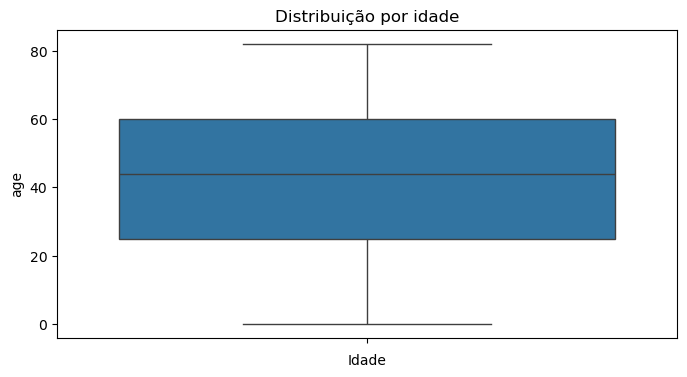

In [136]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df["age"])
plt.title("Distribuição por idade")
plt.xlabel("Idade")
plt.show()

In [137]:
max(df["age"])

82.0

In [138]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [139]:
columns_to_encode = ['gender']
encoded_data = encoder.fit_transform(df[columns_to_encode])
encoder.categories_

[array(['Female', 'Male', 'Other'], dtype=object)]

In [140]:
encoded_test_data = encoder.transform(d_train[columns_to_encode])
encoded_test_data

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(4909, 3))

In [141]:
future_names = encoder.get_feature_names_out(columns_to_encode)
future_names

array(['gender_Female', 'gender_Male', 'gender_Other'], dtype=object)

In [142]:
encoded_df = pd.DataFrame(encoded_data, columns=future_names)
encoded_df

,gender_Female,gender_Male,gender_Other
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0
...,...,...,...
4904,1.0,0.0,0.0
4905,1.0,0.0,0.0
4906,1.0,0.0,0.0
4907,0.0,1.0,0.0


In [143]:
df['gender'].unique()
df.isnull().sum()
encoded_df.index = df.index
df = pd.concat([df, encoded_df], axis=1)
df = df.drop('gender', axis=1)

In [144]:
df

,id,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other
0,9046,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0,0.0
2,31112,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0,0.0
3,60182,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1.0,0.0,0.0
4,1665,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1.0,0.0,0.0
5,56669,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0,1.0,0.0,0.0
5106,44873,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,1.0,0.0,0.0
5107,19723,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,1.0,0.0,0.0
5108,37544,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,0.0,1.0,0.0


# Marriage status

In [145]:
encoder = OneHotEncoder(sparse_output=False)

In [146]:
columns_to_encode = ['ever_married']
encoded_data = encoder.fit_transform(df[columns_to_encode])
encoder.categories_

[array(['No', 'Yes'], dtype=object)]

In [147]:
encoded_test_data = encoder.transform(d_train[columns_to_encode])
encoded_test_data

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], shape=(4909, 2))

In [148]:
future_names = encoder.get_feature_names_out(columns_to_encode)
future_names

array(['ever_married_No', 'ever_married_Yes'], dtype=object)

In [149]:
encoded_df = pd.DataFrame(encoded_data, columns=future_names)
encoded_df

,ever_married_No,ever_married_Yes
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
4904,1.0,0.0
4905,0.0,1.0
4906,0.0,1.0
4907,0.0,1.0


In [150]:
df['ever_married'].unique()
df.isnull().sum()
encoded_df.index = df.index
df = pd.concat([df, encoded_df], axis=1)
df = df.drop('ever_married', axis=1)

In [151]:
df

,id,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes
0,9046,67.0,0,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0,1.0
2,31112,80.0,0,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0,0.0,0.0,1.0
3,60182,49.0,0,0,Private,Urban,171.23,34.4,smokes,1,1.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,Self-employed,Rural,174.12,24.0,never smoked,1,1.0,0.0,0.0,0.0,1.0
5,56669,81.0,0,0,Private,Urban,186.21,29.0,formerly smoked,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,14180,13.0,0,0,children,Rural,103.08,18.6,Unknown,0,1.0,0.0,0.0,1.0,0.0
5106,44873,81.0,0,0,Self-employed,Urban,125.20,40.0,never smoked,0,1.0,0.0,0.0,0.0,1.0
5107,19723,35.0,0,0,Self-employed,Rural,82.99,30.6,never smoked,0,1.0,0.0,0.0,0.0,1.0
5108,37544,51.0,0,0,Private,Rural,166.29,25.6,formerly smoked,0,0.0,1.0,0.0,0.0,1.0


# Glucose level

Text(0.5, 1.0, 'Histograma de Glucose')

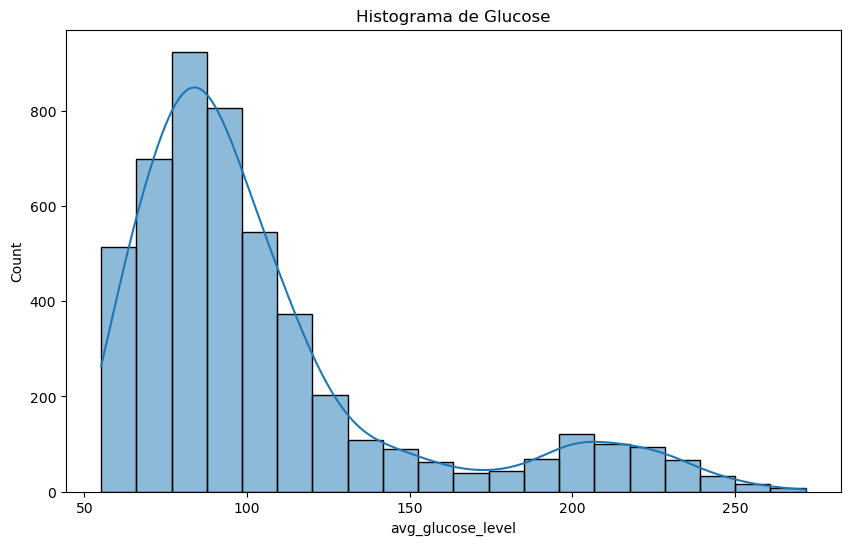

In [152]:
plt.figure(figsize=(10, 6))
sns.histplot(data = df["avg_glucose_level"], bins=20, kde=True)
plt.title("Histograma de Glucose")

In [153]:
max(df["avg_glucose_level"])

271.74

In [154]:
df[df["avg_glucose_level"] >= 180]

,id,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes
0,9046,67.0,0,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0,1.0
5,56669,81.0,0,0,Private,Urban,186.21,29.0,formerly smoked,1,0.0,1.0,0.0,0.0,1.0
14,5317,79.0,0,1,Private,Urban,214.09,28.2,never smoked,1,1.0,0.0,0.0,0.0,1.0
16,56112,64.0,0,1,Private,Urban,191.61,37.5,smokes,1,0.0,1.0,0.0,0.0,1.0
17,34120,75.0,1,0,Private,Urban,221.29,25.8,smokes,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5034,65405,79.0,0,0,Private,Urban,253.86,28.8,formerly smoked,0,1.0,0.0,0.0,1.0,0.0
5035,49773,78.0,0,0,Private,Urban,203.36,28.7,formerly smoked,0,1.0,0.0,0.0,0.0,1.0
5061,38009,41.0,0,0,Private,Urban,223.78,32.3,never smoked,0,0.0,1.0,0.0,0.0,1.0
5062,11184,82.0,0,0,Self-employed,Rural,211.58,36.9,never smoked,0,1.0,0.0,0.0,0.0,1.0


# Hypertension and heart disease

In [155]:
df[df["hypertension"] == 1]

,id,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes
4,1665,79.0,1,0,Self-employed,Rural,174.12,24.0,never smoked,1,1.0,0.0,0.0,0.0,1.0
6,53882,74.0,1,1,Private,Rural,70.09,27.4,never smoked,1,0.0,1.0,0.0,0.0,1.0
10,12109,81.0,1,0,Private,Rural,80.43,29.7,never smoked,1,1.0,0.0,0.0,0.0,1.0
15,58202,50.0,1,0,Self-employed,Rural,167.41,30.9,never smoked,1,1.0,0.0,0.0,0.0,1.0
17,34120,75.0,1,0,Private,Urban,221.29,25.8,smokes,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,10995,76.0,1,0,Private,Rural,267.60,30.5,never smoked,0,0.0,1.0,0.0,0.0,1.0
4987,67012,64.0,1,0,Private,Rural,196.26,34.5,Unknown,0,0.0,1.0,0.0,0.0,1.0
5088,22190,64.0,1,0,Self-employed,Urban,76.89,30.2,Unknown,0,1.0,0.0,0.0,0.0,1.0
5091,6369,59.0,1,0,Private,Rural,95.05,30.9,never smoked,0,0.0,1.0,0.0,0.0,1.0


In [156]:
df[df["heart_disease"] == 1]

,id,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes
0,9046,67.0,0,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0,1.0
2,31112,80.0,0,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0,0.0,0.0,1.0
6,53882,74.0,1,1,Private,Rural,70.09,27.4,never smoked,1,0.0,1.0,0.0,0.0,1.0
11,12095,61.0,0,1,Govt_job,Rural,120.46,36.8,smokes,1,1.0,0.0,0.0,0.0,1.0
14,5317,79.0,0,1,Private,Urban,214.09,28.2,never smoked,1,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4784,70497,81.0,1,1,Private,Rural,126.34,27.4,smokes,0,1.0,0.0,0.0,0.0,1.0
4855,42563,57.0,1,1,Private,Rural,231.72,45.7,formerly smoked,0,1.0,0.0,0.0,0.0,1.0
4869,72715,50.0,0,1,Private,Urban,193.80,26.4,never smoked,0,1.0,0.0,0.0,0.0,1.0
4986,53697,58.0,0,1,Private,Rural,225.35,26.5,smokes,0,0.0,1.0,0.0,0.0,1.0


# New dataframe

In [157]:
df_0 = df.drop(["work_type", "Residence_type", "smoking_status", "ever_married_No", "ever_married_Yes"], axis=1)

In [158]:
df_0

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other
0,9046,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,1,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,1,1.0,0.0,0.0
4,1665,79.0,1,0,174.12,24.0,1,1.0,0.0,0.0
5,56669,81.0,0,0,186.21,29.0,1,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
5104,14180,13.0,0,0,103.08,18.6,0,1.0,0.0,0.0
5106,44873,81.0,0,0,125.20,40.0,0,1.0,0.0,0.0
5107,19723,35.0,0,0,82.99,30.6,0,1.0,0.0,0.0
5108,37544,51.0,0,0,166.29,25.6,0,0.0,1.0,0.0


In [159]:
df_0 = df[df["hypertension"] == 1]
df_0 = df_0[df_0["heart_disease"] == 1]
df_0 = df_0[df_0["avg_glucose_level"] >= 180]
df_0 = df_0.drop(["id", "work_type", "Residence_type", "smoking_status", "ever_married_No", "ever_married_Yes"], axis=1)

In [160]:
df_0

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other
115,71.0,1,1,216.94,30.9,1,0.0,1.0,0.0
187,82.0,1,1,215.94,27.9,1,1.0,0.0,0.0
193,68.0,1,1,271.74,31.1,1,0.0,1.0,0.0
217,55.0,1,1,210.40,40.0,1,1.0,0.0,0.0
220,81.0,1,1,250.89,28.1,1,0.0,1.0,0.0
243,68.0,1,1,247.51,40.5,1,1.0,0.0,0.0
350,79.0,1,1,200.28,30.0,0,1.0,0.0,0.0
970,75.0,1,1,195.03,28.7,0,0.0,1.0,0.0
1067,67.0,1,1,254.63,31.0,0,0.0,1.0,0.0
1189,73.0,1,1,230.68,37.7,0,0.0,1.0,0.0


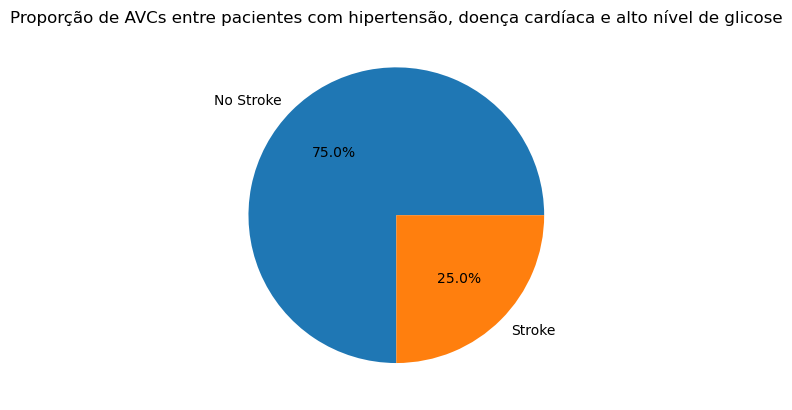

In [161]:
plt.pie(df_0["stroke"].value_counts(), labels=["No Stroke", "Stroke"], autopct="%1.1f%%")
plt.title("Proporção de AVCs entre pacientes com hipertensão, doença cardíaca e alto nível de glicose")
plt.show()

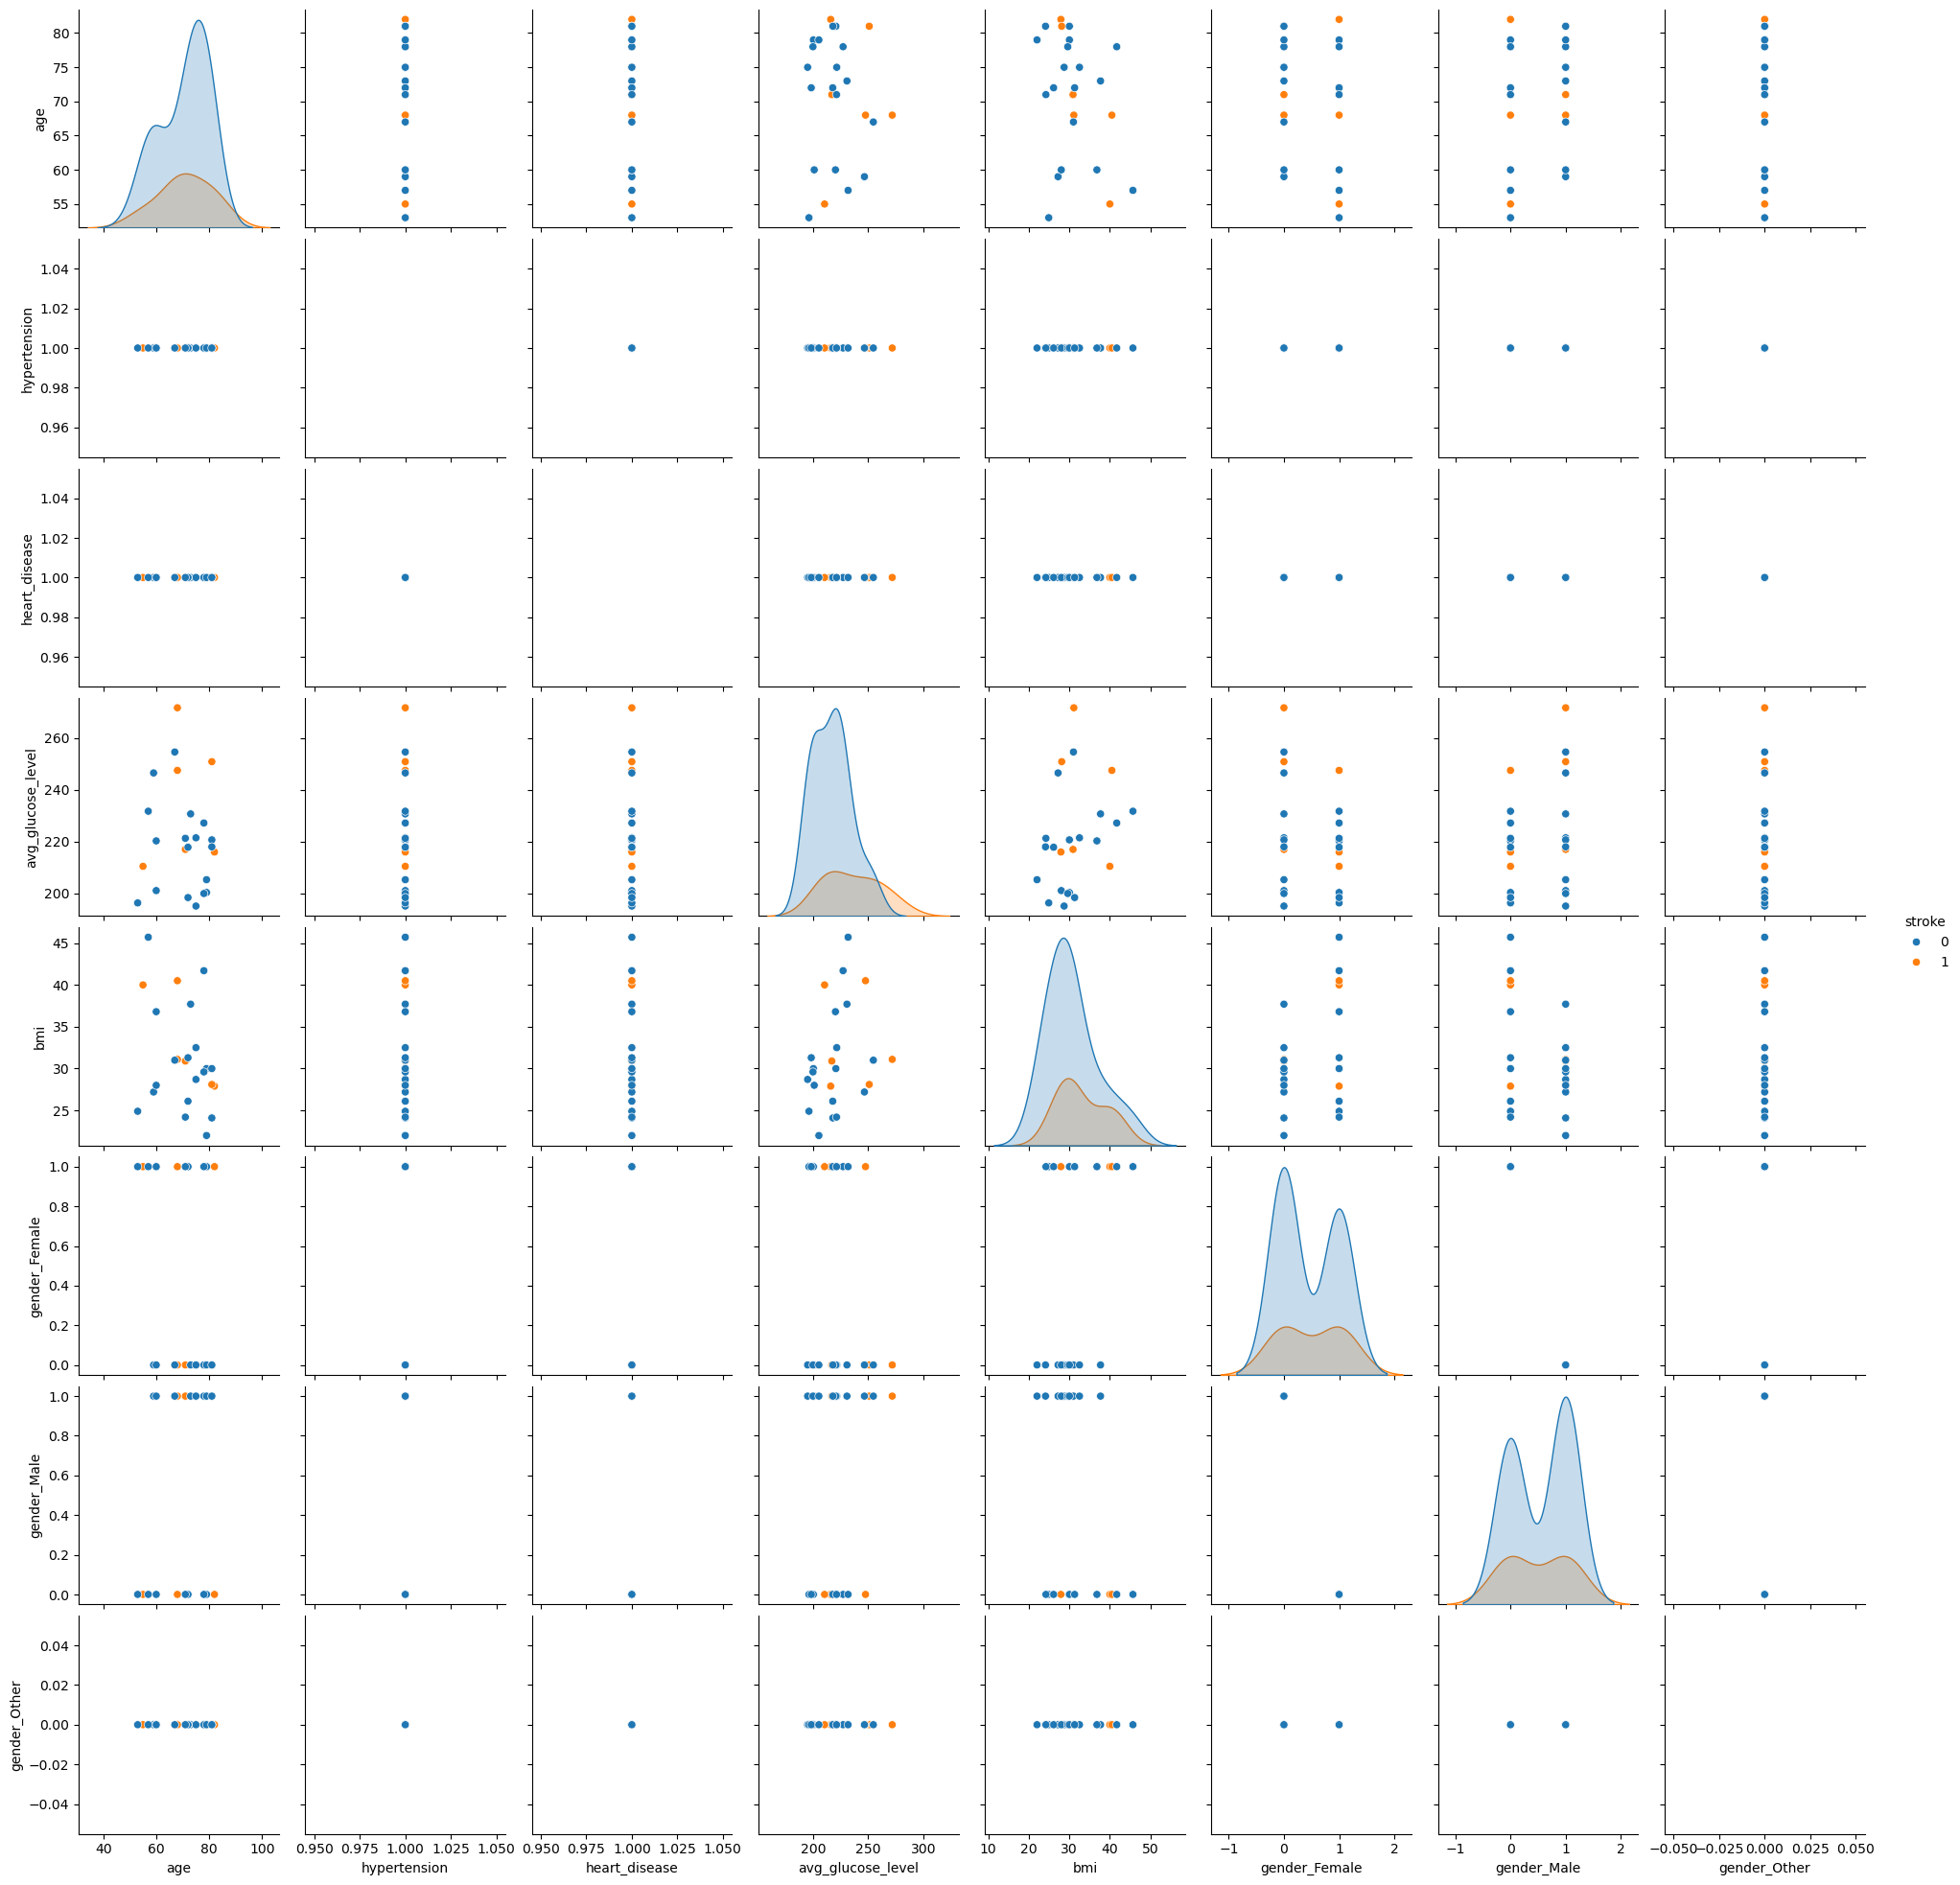

In [162]:
sns.pairplot(df_0, hue="stroke")
plt.show()

In [163]:
X = df.drop('stroke', axis=1)
y = df['stroke']
X = pd.get_dummies(X, drop_first=True) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [164]:
cm = confusion_matrix(y_test, y_pred)

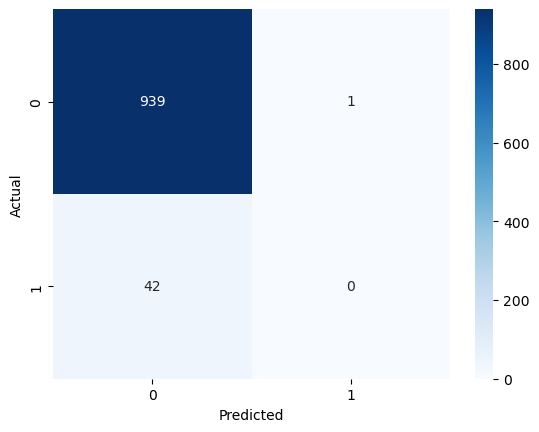

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       940
           1       0.00      0.00      0.00        42

    accuracy                           0.96       982
   macro avg       0.48      0.50      0.49       982
weighted avg       0.92      0.96      0.94       982



In [165]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()
print(classification_report(y_test, y_pred))


In [167]:
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
df['stroke'].value_counts() 

X = df_0.drop(columns=['stroke']) 
y = df_0['stroke'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) 

clf = tree.DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

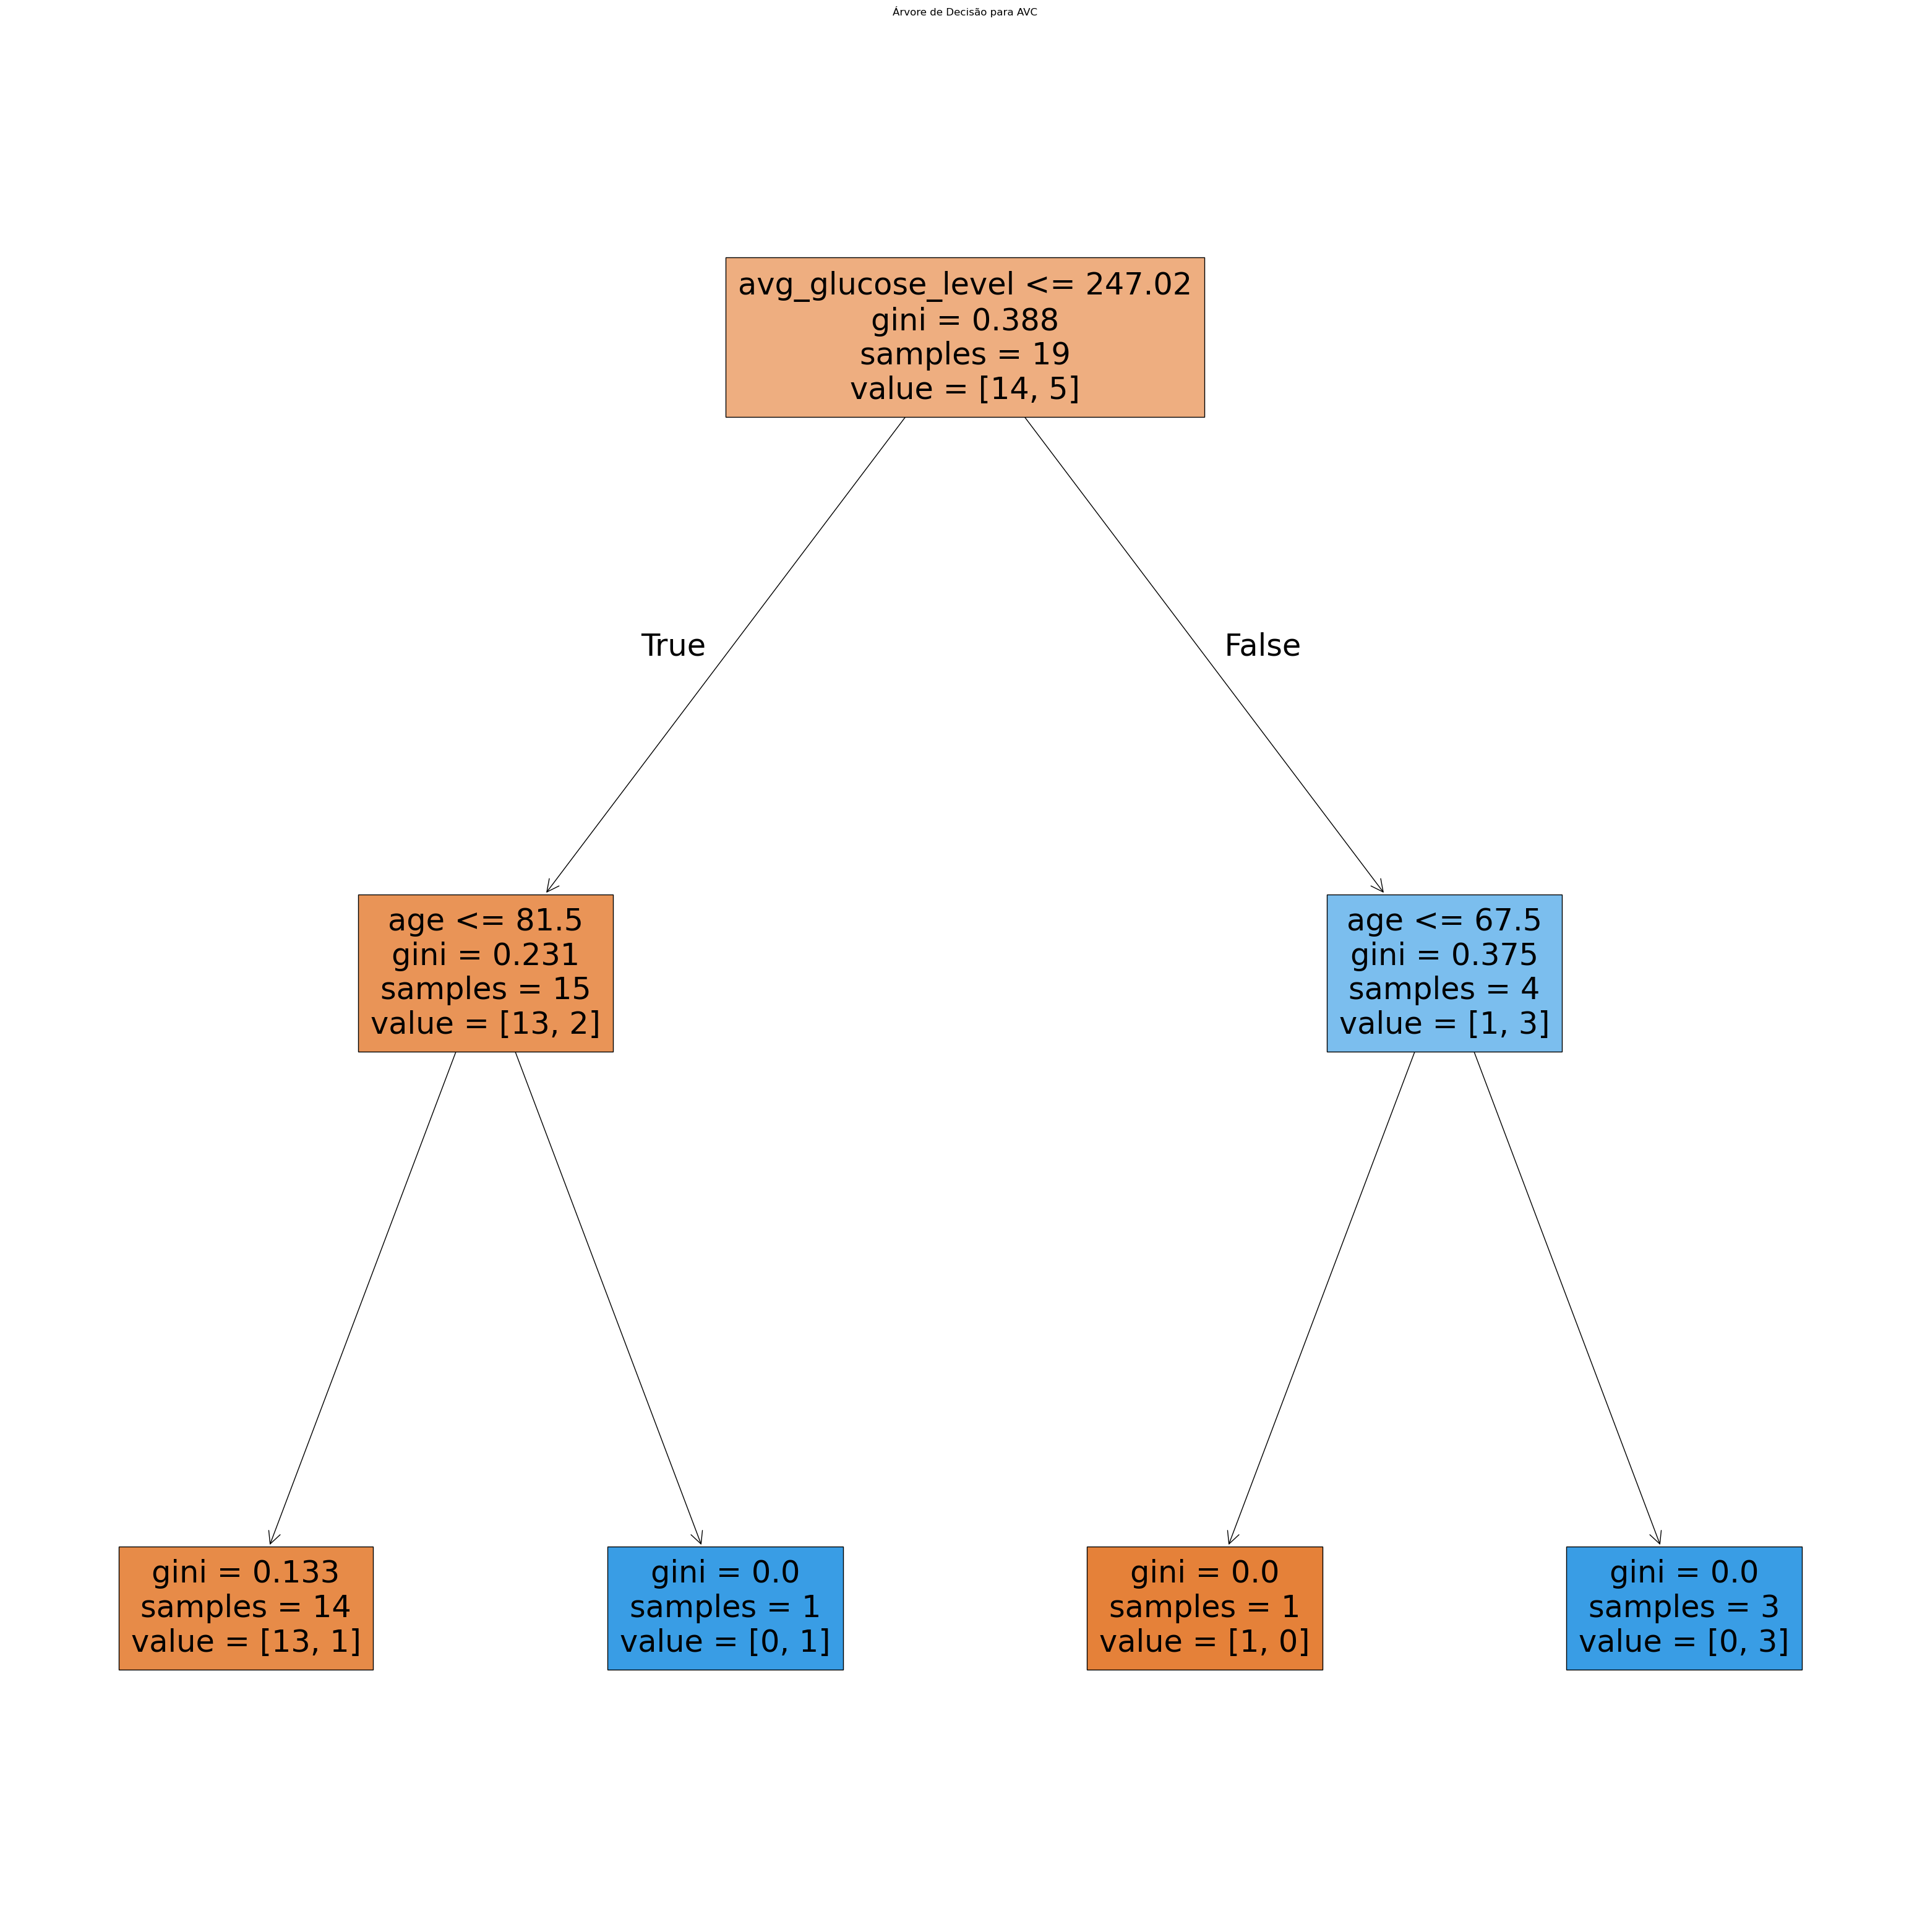

Precisão do modelo: 0.80


In [168]:

plt.figure(figsize=(40,40))
plot_tree(clf, filled=True, feature_names=X.columns)
plt.title("Árvore de Decisão para AVC")
plt.show()

accuracy= np.mean(y_pred == y_test)
print(f"Precisão do modelo: {accuracy:.2f}")